<a href="https://colab.research.google.com/github/RidhimaGupta-econ/US-Airline-Passenger-Demand-Forecasting/blob/main/US_Airline_Passenger_Demand_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving ARDL_DATA.xlsx to ARDL_DATA (2).xlsx
User uploaded file "ARDL_DATA (2).xlsx" with length 16497 bytes


In [ ]:
df = pd.read_excel('ARDL_DATA (1).xlsx')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      124 non-null    datetime64[ns]
 1   GDP                       124 non-null    float64       
 2   Consumption               124 non-null    float64       
 3   M2_MoneySupply            124 non-null    float64       
 4   Inflation_CPI_YoY         124 non-null    float64       
 5   InterestRate              124 non-null    float64       
 6   ExchangeRate_LCU_per_USD  124 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 6.9 KB


In [ ]:
df.head()

,date,GDP,Consumption,M2_MoneySupply,Inflation_CPI_YoY,InterestRate,ExchangeRate_LCU_per_USD
0,1995-01-01,102.66,81.73,51.55,3.00,0.25,45.00
1,1995-04-01,105.21,85.51,54.33,3.00,3.15,43.87
2,1995-07-01,106.94,86.59,56.48,2.24,4.80,43.02
3,1995-10-01,110.94,87.15,60.18,2.26,5.39,42.62
4,1996-01-01,111.61,88.68,60.08,2.95,5.37,42.76


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      124 non-null    datetime64[ns]
 1   GDP                       124 non-null    float64       
 2   Consumption               124 non-null    float64       
 3   M2_MoneySupply            124 non-null    float64       
 4   Inflation_CPI_YoY         124 non-null    float64       
 5   InterestRate              124 non-null    float64       
 6   ExchangeRate_LCU_per_USD  124 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 6.9 KB


In [ ]:
df.describe()


,date,GDP,Consumption,M2_MoneySupply,Inflation_CPI_YoY,InterestRate,ExchangeRate_LCU_per_USD
count,124,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000
mean,2010-05-17 01:32:54.193548288,155.508387,116.304435,111.909274,2.579677,6.019758,50.580484
min,1995-01-01 00:00:00,102.660000,81.730000,51.550000,0.870000,0.250000,37.670000
25%,2002-09-08 00:00:00,122.660000,94.662500,84.132500,2.210000,5.690000,47.005000
50%,2010-05-16 12:00:00,149.525000,113.600000,118.175000,2.650000,6.055000,50.480000
75%,2018-01-23 12:00:00,192.010000,137.507500,135.807500,2.982500,6.412500,56.440000
max,2025-10-01 00:00:00,223.220000,159.660000,166.220000,4.390000,7.550000,59.950000
std,NaN,35.239997,22.928755,31.313982,0.678875,0.768220,6.153078


In [ ]:
df.isnull().sum()

,0
date,0
GDP,0
Consumption,0
M2_MoneySupply,0
Inflation_CPI_YoY,0
InterestRate,0
ExchangeRate_LCU_per_USD,0


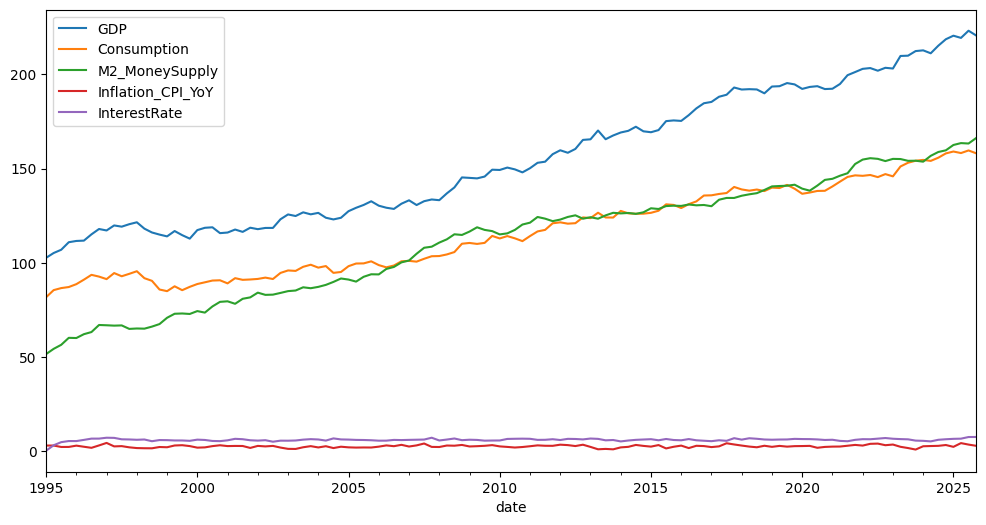

In [ ]:
import matplotlib.pyplot as plt
df.set_index("date")[["GDP","Consumption","M2_MoneySupply","Inflation_CPI_YoY","InterestRate"]].plot(figsize=(12,6))
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller


In [ ]:
def adf_test(series, name):
  result = adfuller(series.dropna())
  print ("variables:", name)
  print ("ADF Statistic:", result[0])
  print ("p-value:", result[1])
  print ("Critical Values:",)
  for key, value in result[4].items():
    print (f"{key} :{value}")
    print()
    for variable in  ["GDP","Consumption","M2_MoneySupply","Inflation_CPI_YoY","InterestRate", "ExchangeRate_LCU_per_USD"]:
     adf_test(df[variable], variable)

## 1. Establishing the Order of Integration

To perform ARDL bounds testing, we first need to determine the order of integration of the variables. We will use the Augmented Dickey-Fuller (ADF) test for this purpose. The ADF test checks for the presence of a unit root in a time series, which indicates non-stationarity.

*   **Null Hypothesis (H0):** The time series has a unit root (is non-stationary).
*   **Alternative Hypothesis (H1):** The time series does not have a unit root (is stationary).

If the p-value is less than a significance level (e.g., 0.05), we reject the null hypothesis and conclude that the series is stationary.

In [ ]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, title=''):
    print(f'Augmented Dickey-Fuller Test for: {title}')
    result = adfuller(series.dropna(), autolag='AIC')
    labels = ['ADF Statistic', 'p-value', '#Lags Used', 'Number of Observations Used']
    for value, label in zip(result, labels):
        print(f'{label}: {value:.4f}')
    if result[1] <= 0.05:
        print("Conclusion: Reject H0 (Stationary)")
    else:
        print("Conclusion: Fail to reject H0 (Non-stationary)")
    print('\n')

# Perform ADF test on 'Inflation_CPI_YoY'
adf_test(df['Inflation_CPI_YoY'], title='Inflation_CPI_YoY (Level)')

# Perform ADF test on 'M2_MoneySupply'
adf_test(df['M2_MoneySupply'], title='M2_MoneySupply (Level)')

# Perform ADF test on 'InterestRate'
adf_test(df['InterestRate'], title='InterestRate (Level)')


Augmented Dickey-Fuller Test for: Inflation_CPI_YoY (Level)
ADF Statistic: -7.0027
p-value: 0.0000
#Lags Used: 0.0000
Number of Observations Used: 123.0000
Conclusion: Reject H0 (Stationary)


Augmented Dickey-Fuller Test for: M2_MoneySupply (Level)
ADF Statistic: -0.9662
p-value: 0.7654
#Lags Used: 0.0000
Number of Observations Used: 123.0000
Conclusion: Fail to reject H0 (Non-stationary)


Augmented Dickey-Fuller Test for: InterestRate (Level)
ADF Statistic: -5.6419
p-value: 0.0000
#Lags Used: 4.0000
Number of Observations Used: 119.0000
Conclusion: Reject H0 (Stationary)




/tmp/ipykernel_5568/3506556554.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna(), autolag='AIC')
/tmp/ipykernel_5568/3506556554.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna(), autolag='AIC')
/tmp/ipykernel_5568/3506556554.py:5: FutureWarning: adfuller currently returns a plain tuple whose length de

In [ ]:
# Perform ADF test on the first difference of 'M2_MoneySupply'
df['M2_MoneySupply_diff'] = df['M2_MoneySupply'].diff().dropna()
adf_test(df['M2_MoneySupply_diff'], title='M2_MoneySupply (First Difference)')

Augmented Dickey-Fuller Test for: M2_MoneySupply (First Difference)
ADF Statistic: -9.7918
p-value: 0.0000
#Lags Used: 0.0000
Number of Observations Used: 122.0000
Conclusion: Reject H0 (Stationary)




/tmp/ipykernel_5568/3506556554.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna(), autolag='AIC')


In [ ]:
# Perform ADF test on 'GDP'
adf_test(df['GDP'], title='GDP (Level)')

# Perform ADF test on 'Consumption'
adf_test(df['Consumption'], title='Consumption (Level)')

# Perform ADF test on 'ExchangeRate_LCU_per_USD'
adf_test(df['ExchangeRate_LCU_per_USD'], title='ExchangeRate_LCU_per_USD (Level)')

Augmented Dickey-Fuller Test for: GDP (Level)
ADF Statistic: 0.5492
p-value: 0.9863
#Lags Used: 0.0000
Number of Observations Used: 123.0000
Conclusion: Fail to reject H0 (Non-stationary)


Augmented Dickey-Fuller Test for: Consumption (Level)
ADF Statistic: 0.2071
p-value: 0.9727
#Lags Used: 0.0000
Number of Observations Used: 123.0000
Conclusion: Fail to reject H0 (Non-stationary)


Augmented Dickey-Fuller Test for: ExchangeRate_LCU_per_USD (Level)
ADF Statistic: -0.3158
p-value: 0.9232
#Lags Used: 0.0000
Number of Observations Used: 123.0000
Conclusion: Fail to reject H0 (Non-stationary)




/tmp/ipykernel_5568/3506556554.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna(), autolag='AIC')
/tmp/ipykernel_5568/3506556554.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna(), autolag='AIC')
/tmp/ipykernel_5568/3506556554.py:5: FutureWarning: adfuller currently returns a plain tuple whose length de

## 2. ARDL Bounds-Testing for Cointegration

With the order of integration established for each variable, we can now proceed to test for a long-run cointegrating relationship using the Autoregressive Distributed Lag (ARDL) bounds test developed by Pesaran, Shin, and Smith (2001).

**Hypotheses for the Bounds Test:**
*   **Null Hypothesis (H0):** No long-run cointegrating relationship exists.
*   **Alternative Hypothesis (H1):** A long-run cointegrating relationship exists.

The bounds test involves an F-statistic. If the calculated F-statistic falls above the upper bound critical value, we reject the null hypothesis, implying cointegration. If it falls below the lower bound critical value, we fail to reject the null hypothesis. If it falls between the two bounds, the result is inconclusive.

We will treat `Inflation_CPI_YoY` as the dependent variable ($Y$) and `M2_MoneySupply` and `InterestRate` as the independent variables ($X$) in our ARDL model. We will first install the `ardl` package, which provides functionalities for this test.

In [ ]:
# Install the ardl package if not already installed
!pip install ardl

import pandas as pd
from ardl import ARDL
from ardl.bounds_test import bounds_f_test

# Ensure the date column is in datetime format and set as index
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

# Define dependent and independent variables
y = df['Inflation_CPI_YoY']
X = df[['M2_MoneySupply', 'InterestRate']]

# Set maximum lags. A common choice for quarterly data is up to 4 or 8.
# We will use (4, 4) for (dependent_lags, independent_lags)
max_lags = (4, 4)

# Perform the ARDL bounds F-test
# We choose 'restricted_trend' as it implies a constant but no deterministic trend
f_test_result = bounds_f_test(y, X, max_lags=max_lags, model='restricted_trend', significance=0.05)

print("\nARDL Bounds F-test Result:")
print(f_test_result)


ERROR: Could not find a version that satisfies the requirement ardl (from versions: none)
ERROR: No matching distribution found for ardl


ModuleNotFoundError: No module named 'ardl'

If any of the series are found to be non-stationary at level, we will then test their first differences.

In [ ]:
import pandas as pd
from statsmodels.tsa.ardl import ARDL

df= pd.read_excel("ARDL_DATA (1).xlsx")

model= ARDL(
    df["GDP"],
    lags=1,
    exog = df[["Consumption", "M2_MoneySupply","InterestRate"]],
    order=1
)

result=model.fit()
print(result.summary())
#

                              ARDL Model Results                              
Dep. Variable:                    GDP   No. Observations:                  123
Model:               ARDL(1, 1, 1, 1)   Log Likelihood                -203.023
Method:               Conditional MLE   S.D. of innovations              1.261
Date:                Mon, 28 Sep 2026   AIC                            424.047
Time:                        08:34:12   BIC                            449.356
Sample:                             1   HQIC                           434.327
                                  124                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -6.6849      1.905     -3.509      0.001     -10.458      -2.912
GDP.L1                0.7672      0.050     15.313      0.000       0.668       0.866
Consumption.L0        0.

In [ ]:
 ecm_alpha = result.params['GDP.L1']
print(f"error correction term (alpha): {ecm_alpha}")


error correction term (alpha): 0.7671557905925398
